# **ANALISIS SENTIMEN AVETA HOTEL MALIOBORO**

**Import Library**

In [240]:
# Optional dependency setup (jalankan bila modul belum terpasang)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "Sastrawi", "wordcloud"])
print("Dependency check complete")


Dependency check complete


In [241]:
# Model Librari
import pandas as pd
import re
import string
import requests
import ast
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Auto-install minimal dependency if missing
import subprocess, sys
try:
    import nltk
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk

try:
    from wordcloud import WordCloud
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    from wordcloud import WordCloud

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "Sastrawi"])
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.naive_bayes import ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC


In [242]:
# Reproducibility setup
import random
np.random.seed(42)
random.seed(42)
print("Random seed set to 42")


Random seed set to 42


Import Data

In [ ]:
from pathlib import Path

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
source = None

for candidate in candidates:
    direct = candidate / 'data' / 'prosses' / 'hasil_labeling_aveta_transformer_tr.csv'
    nested = candidate / 'analisis' / 'data' / 'prosses' / 'hasil_labeling_aveta_transformer_tr.csv'
    if direct.exists():
        source = direct
        break
    if nested.exists():
        source = nested
        break

if source is None:
    raise FileNotFoundError('File hasil_labeling_aveta_transformer_tr.csv tidak ditemukan dari direktori kerja saat ini.')

data = pd.read_csv(source)
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]
ACTIVE_RAW_DATASET = str(source)
print(f"Raw dataset aktif: {source}")
print(f"Total data: {len(data)}")
data.head()


Raw dataset aktif: D:\PROYEK TUGAS AKHIR\APP TA\analisis\data\audit_tr\hasil_labeling_aveta_transformer_tr.csv
Total data: 2449


,rating,ulasan,label
0,5/5,Hotel yang sangat strategis di Jalan Malioboro...,Negatif
1,5/5,Lokasi teratas. Di sekitar lokasi hotel banyak...,Positif
2,2/5,Saya tidak cukup merekomendasikannya. Memesan ...,Negatif
3,5/5,Menginap 2 hari 2 malam bersama istri dan anak...,Positif
4,2/5,Saya memberikan ini 2 bintang sebelum saya mem...,Negatif


**Distribusi Data**

In [6]:
jumlah = data['label'].value_counts(dropna=False)
persen = data['label'].value_counts(dropna=False, normalize=True) * 100
hasil = pd.DataFrame({
    'Jumlah': jumlah,
    'Persentase (%)': persen.round(2)
})
print(hasil)


         Jumlah  Persentase (%)
label                          
Positif    2152           87.87
Negatif     250           10.21
NaN          47            1.92


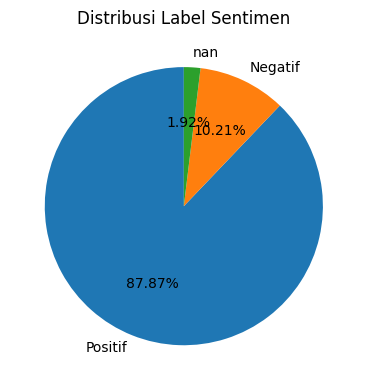

In [7]:
# Visualisasi Distribusi Label
jumlah = data['label'].value_counts(dropna=False)
persen = data['label'].value_counts(dropna=False, normalize=True) * 100

plt.figure(figsize=(4,4))
plt.pie(
    jumlah.values,
    labels=jumlah.index.astype(str),
    autopct=lambda p: f"{p:.2f}%",
    startangle=90
)
plt.title('Distribusi Label Sentimen')
plt.tight_layout()
plt.show()


In [8]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2449 entries, 0 to 2448
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rating  2449 non-null   object
 1   ulasan  2449 non-null   object
 2   label   2402 non-null   object
dtypes: object(3)
memory usage: 57.5+ KB


In [9]:
data.describe()


,rating,ulasan,label
count,2449,2449,2402
unique,7,2323,2
top,5/5,Bagus,Positif
freq,1853,23,2152


In [10]:
# **Cek Data Unlabeled dan Missing Value**
persentase = data['label'].isna().mean() * 100
print(f"Persentase data tanpa label: {persentase:.2f}%")
# Missing Value
data = data.dropna()
data.isnull().sum()


Persentase data tanpa label: 1.92%


rating    0
ulasan    0
label     0
dtype: int64

In [11]:
total = len(data)
kosong = data['label'].isna().sum()
data = data.dropna(subset=['label']) #drop data unlabeled
print(f"Total data       : {total}")
print(f"Tanpa label      : {kosong}")
print(f"Persentase (%)   : {kosong/total*100:.2f}%")


Total data       : 2402
Tanpa label      : 0
Persentase (%)   : 0.00%


In [12]:
# Analisis Distribusi Label Setelah Menghapus Data Unlabeled
jumlah = data['label'].value_counts(dropna=False)
persen = data['label'].value_counts(dropna=False, normalize=True) * 100
hasil = pd.DataFrame({
    'Jumlah': jumlah,
    'Persentase (%)': persen.round(2)
})
print(hasil)

         Jumlah  Persentase (%)
label                          
Positif    2152           89.59
Negatif     250           10.41


In [14]:
# Cek Data yang memiliki review yang sama di tabel Ulasan

duplikat = data[data.duplicated(subset=['ulasan'], keep=False)].sort_values('ulasan')
print(f"Jumlah baris duplikat: {len(duplikat)}")
duplikat


Jumlah baris duplikat: 164


,rating,ulasan,label
2320,5/5,Bagus,Positif
2343,5/5,Bagus,Positif
2298,5/5,Bagus,Positif
2295,5/5,Bagus,Positif
2305,5/5,Bagus,Positif
...,...,...,...
2165,5/5,Wajar,Positif
1964,5/5,makanannya enak,Positif
1953,4/5,makanannya enak,Positif
2179,5/5,sangat bagus,Positif


In [16]:
# 1) Drop exact duplicate rows (semua kolom sama)
data = data.drop_duplicates()

# 2) Drop konflik label untuk ulasan yang sama
# cari ulasan yang punya >1 label berbeda
teks_sama = (
    data.groupby('ulasan')['label']
        .nunique()
        .loc[lambda s: s > 1]
        .index
)

# buang semua baris yang konflik
data = data[~data['ulasan'].isin(teks_sama)].reset_index(drop=True)

print(f"Setelah bersih: {len(data)} baris")
print(f"Konflik yang dibuang: {len(teks_sama)} teks ulasan")


Setelah bersih: 2306 baris
Konflik yang dibuang: 0 teks ulasan


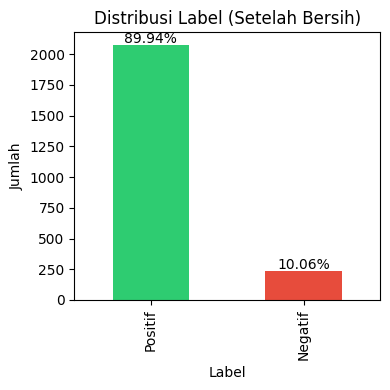

In [17]:

# asumsi data sudah bersih dari NaN & duplikat
jumlah = data['label'].value_counts(dropna=False)
persen = data['label'].value_counts(dropna=False, normalize=True) * 100

plt.figure(figsize=(4,4))
ax = jumlah.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
ax.set_title('Distribusi Label (Setelah Bersih)')
ax.set_ylabel('Jumlah')
ax.set_xlabel('Label')

for i, v in enumerate(jumlah.values):
    ax.text(i, v + (jumlah.max()*0.01), f"{persen.iloc[i]:.2f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [15]:
# data.to_csv('data/processed/data_aveta.csv', index=False)


Setelah Melakukan Drop Data Nan dan Duplicated

In [16]:
# from pathlib import Path
# base = Path.cwd()
# if not (base / 'data' / 'processed').exists():
#     base = base.parent  # kalau notebook dijalankan dari folder analisis

# source = base / 'data' / 'processed' / 'data_aveta.csv'
# data = pd.read_csv(source)
# data = data.loc[:, ~data.columns.str.contains("^Unnamed")]
# print(f"Total data: {len(data)}")
# data.head()


In [20]:
# Missing values
missing = data.isna().sum().to_frame('missing')
print(missing)

# Duplikat baris penuh
dup_rows = data.duplicated().sum()
print(f"Duplikat baris penuh: {dup_rows}")

# Duplikat berdasarkan ulasan saja (lebih relevan)
dup_ulasan = data.duplicated(subset=['ulasan']).sum()
print(f"Duplikat berdasarkan ulasan: {dup_ulasan}")


        missing
rating        0
ulasan        0
label         0
Duplikat baris penuh: 0
Duplikat berdasarkan ulasan: 24


In [23]:
duplikat_ulasan = data[data.duplicated(subset=['ulasan'], keep=False)].sort_values('ulasan')
print(duplikat_ulasan)


     rating                                             ulasan    label
1560    5/5                                              Bagus  Positif
2140    3/5                                              Bagus  Positif
2200    4/5                                              Bagus  Positif
2113    3/5                                  Bersih dan nyaman  Positif
1441    5/5                                  Bersih dan nyaman  Positif
2244    4/5                                  Bersih dan nyaman  Positif
2060    4/5                                              Besar  Positif
2180    5/5                                              Besar  Positif
2181    1/5                                              Besar  Positif
2241    5/5                                   Direkomendasikan  Negatif
1863  4,1/5                                   Direkomendasikan  Negatif
2206    4/5                                   Direkomendasikan  Negatif
1027    5/5  Error 500 (Server Error)!!1500.Thatâs an err...  

In [24]:
# Drop lagi duplikat berdasarkan ulasan
data = data.drop_duplicates(subset=['ulasan'], keep=False).reset_index(drop=True)
print(f"Setelah drop duplikat ulasan: {len(data)} baris")

Setelah drop duplikat ulasan: 2263 baris


In [25]:
jumlah = data['label'].value_counts(dropna=False)
persen = data['label'].value_counts(dropna=False, normalize=True) * 100
hasil = pd.DataFrame({
    'Jumlah': jumlah,
    'Persentase (%)': persen.round(2)
})
print(hasil)


         Jumlah  Persentase (%)
label                          
Positif    2042           90.23
Negatif     221            9.77


In [26]:
total_negatif = len(data[data['label'] == "Negatif"])
total_positif = len(data[data['label'] == "Positif"])


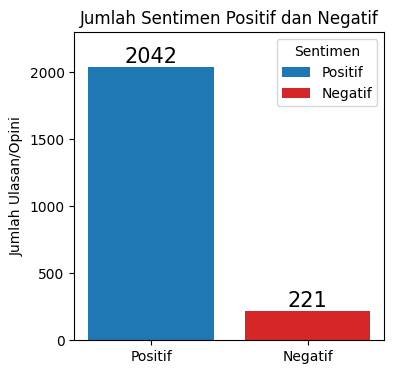

In [27]:
fig, ax = plt.subplots(figsize=(4,4))
fruits = ['Positif', 'Negatif']
counts = [total_positif, total_negatif]
bar_labels = fruits
bar_colors = ['tab:blue', 'tab:red']
bar_container = ax.bar(fruits, counts, label=bar_labels, color=bar_colors)
ax.bar_label(bar_container, size = 15)
ax.set_ylim(0, 2300)
ax.set_ylabel('Jumlah Ulasan/Opini')
ax.set_title('Jumlah Sentimen Positif dan Negatif')
ax.legend(title='Sentimen')
plt.show()


**NLP (Natural Language Processing)**

WordCloud Sebelum Preperosesing

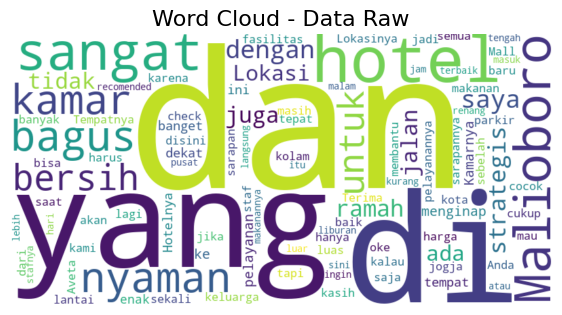

In [29]:
# Visualisasi Word Cloud
text_all = " ".join(data['ulasan'])
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      max_words=100,
                      collocations=False).generate(text_all)
plt.figure(figsize=(7, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Data Raw", fontsize=16)
plt.show()


# **PREPROSESING DATA**

**Case Folding dan Cleaning**

In [30]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() #casefolding

    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Hapus URL/link
    text = re.sub(r'@\w+', '', text) # Hapus mention @username
    text = re.sub(r'#', '', text) # Hapus hastag
    # Konversi rating bintang ke teks
    text = re.sub(r'bintang\s*1', ' bintang satu ', text, flags=re.IGNORECASE) # Jika terdapat bintang 1, dikonversi jadi kata bintang satu
    text = re.sub(r'bintang\s*2', ' bintang dua ', text, flags=re.IGNORECASE)
    text = re.sub(r'bintang\s*3', ' bintang tiga ', text, flags=re.IGNORECASE)
    text = re.sub(r'bintang\s*4', ' bintang empat ', text, flags=re.IGNORECASE)
    text = re.sub(r'bintang\s*5', ' bintang lima ', text, flags=re.IGNORECASE)
    # Cleaning umum
    text = re.sub(r'\d+', '', text) # Hapus angka
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Hapus tanda baca dan karakter non-huruf
    text = re.sub(r'(.)\1{1,}', r'\1', text)  # huruf berulang
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi di awal/akhir
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.encode('ascii', 'ignore').decode('ascii')
    return text
    #apply to ulasan
data['cleaning'] = data['ulasan'].apply(clean_text)

print(data[['ulasan', 'cleaning']].head())


                                              ulasan  \
0  Hotel yang sangat strategis di Jalan Malioboro...   
1  Lokasi teratas. Di sekitar lokasi hotel banyak...   
2  Saya tidak cukup merekomendasikannya. Memesan ...   
3  Menginap 2 hari 2 malam bersama istri dan anak...   
4  Saya memberikan ini 2 bintang sebelum saya mem...   

                                            cleaning  
0  hotel yang sangat strategis di jalan malioboro...  
1  lokasi teratas di sekitar lokasi hotel banyak ...  
2  saya tidak cukup merekomendasikanya memesan ka...  
3  menginap hari malam bersama istri dan anak pua...  
4  saya memberikan ini bintang sebelum saya memas...  


**Tokenize**

In [31]:
from nltk.tokenize import word_tokenize
nltk.download('punkt')

# Pastikan kolom ulasan tersedia dengan nama konsisten
if 'ulasan' not in data.columns and 'ulasan' in data.columns:
    data = data.rename(columns={'ulasan': 'ulasan'})

# Guard: bila cleaning belum dibuat, buat otomatis dari kolom ulasan
if 'cleaning' not in data.columns:
    if 'ulasan' not in data.columns:
        raise KeyError("Kolom 'ulasan' tidak ditemukan. Jalankan cell load data yang benar dulu.")

    if 'clean_text' in globals():
        data['cleaning'] = data['ulasan'].apply(clean_text)
    else:
        # fallback sederhana jika cell clean_text belum dijalankan
        data['cleaning'] = (
            data['ulasan'].astype(str)
            .str.lower()
            .str.replace(r'http\S+|www\S+|https\S+', '', regex=True)
            .str.replace(r'@\w+', '', regex=True)
            .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
            .str.replace(r'\s+', ' ', regex=True)
            .str.strip()
        )

# Fungsi pembungkus tokenisasi
def word_tokenize_wrapper(text):
    if isinstance(text, str):
        return word_tokenize(text)
    return []

# Terapkan tokenisasi pada kolom cleaning
data['tokenize'] = data['cleaning'].apply(word_tokenize_wrapper)
print('Tokenisasi selesai. Kolom tersedia:', [c for c in ['ulasan','cleaning','tokenize'] if c in data.columns])


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenisasi selesai. Kolom tersedia: ['ulasan', 'cleaning', 'tokenize']


**Normalisasi**

In [34]:
from pathlib import Path
import pandas as pd

analisis = Path.cwd()
df_normal = pd.read_csv(analisis / 'data' / 'raw' / 'normalisasi_aveta.csv', sep=';')
df_normal


,kata,normalisasi
0,sgt,sangat
1,jg,juga
2,minusnya,kurang
3,house,rumah
4,keeping,penjaga
...,...,...
1524,lemar,lemari
1525,cil,kecil
1526,nginap,tinggal
1527,inap,tinggal


In [35]:
dict_normal = {}
for awal_kata, normal in zip(df_normal['kata'], df_normal['normalisasi']):
  if awal_kata not in dict_normal:
    dict_normal[awal_kata] = normal


In [36]:
dict_normal


{'sgt': 'sangat',
 'jg': 'juga',
 'minusnya': 'kurang',
 'house ': 'rumah',
 'keeping': 'penjaga',
 'ninggal': 'tinggal',
 'tdk': 'tidak',
 'mnrt': 'menurut',
 'sy': 'saya',
 'enak': 'lezat',
 'lbh': 'lebih',
 'lg': 'lagi',
 'dr': 'dari',
 'rekomended ': 'rekomendasi',
 'minimarket': 'toko kecil',
 'gak': 'tidak',
 'bf': 'sarapan pagi',
 'check inn': 'lapor masuk',
 'free': 'gratis',
 'esok': 'besok',
 'mo': 'ingin',
 'dlm': 'dalam',
 'list': 'daftar',
 'exclude': 'tidak masuk',
 'dgn': 'dengan',
 'nyala': 'hidup',
 'sekelas': 'setara',
 'amenities': 'perlengkapan',
 'yg': 'yang',
 'bener': 'tepat',
 'soo': 'jadi',
 'ae': 'aja',
 'icip': 'coba',
 'no': 'tidak',
 'komen': 'ulasan',
 'nginap': 'tinggal',
 'ank': 'anak',
 'pokoee': 'inti',
 'hrg': 'harga',
 'oke': 'setuju',
 'tidk': 'tidak',
 'tp': 'tapi',
 'krn': 'karena',
 'security': 'satuan pengamanan',
 'taroh': 'taruh',
 'tgl': 'tanggal',
 'booking': 'pesan',
 'wa': 'aplikasi pesan',
 'agak': 'sedikit',
 'defensif': 'bela',
 'early'

In [37]:
normal


'wisata'

In [38]:
def normalize_text(text):
    if not isinstance(text, list):
        return []
    return [
        dict_normal.get(word, word)
        for word in text
        if isinstance(word, str)
    ]
data['normalisasi'] = data['tokenize'].apply(normalize_text)
print(data[['tokenize', 'normalisasi']].head())


                                            tokenize  \
0  [hotel, yang, sangat, strategis, di, jalan, ma...   
1  [lokasi, teratas, di, sekitar, lokasi, hotel, ...   
2  [saya, tidak, cukup, merekomendasikanya, memes...   
3  [menginap, hari, malam, bersama, istri, dan, a...   
4  [saya, memberikan, ini, bintang, sebelum, saya...   

                                         normalisasi  
0  [hotel, yang, sangat, mudah ditemukan, di, jal...  
1  [lokasi, teratas, di, sekitar, lokasi, hotel, ...  
2  [saya, tidak, cukup, merekomendasikanya, memes...  
3  [menginap, hari, malam, bersama, istri, dan, a...  
4  [saya, memberikan, ini, bintang, sebelum, saya...  


  Lemmazitation

In [39]:
def stem_word(word):
    """Menghapus awalan dan akhiran umum Bahasa Indonesia secara sederhana"""
    prefixes = ['meng', 'meny', 'men', 'mem', 'me',
                'peng', 'peny', 'pen', 'pem', 'di', 'ke', 'se',
                'ber', 'ter', 'per', 're'] #awal
    suffixes = ['kan', 'an', 'i', 'lah', 'nya', 'ku', 'mu'] #akhir
    for p in prefixes:
        if word.startswith(p) and len(word) > len(p) + 2:
            word = word[len(p):]
            break
    for s in suffixes:
        if word.endswith(s) and len(word) > len(s) + 2:
            word = word[:-len(s)]
            break
    return word
def stem_sentence(sentence):
    return " ".join([stem_word(w) for w in sentence.split()])
data['lematisasi'] = data['normalisasi'].astype(str).apply(stem_sentence)
print(data[['normalisasi', 'lematisasi']].head())


                                         normalisasi  \
0  [hotel, yang, sangat, mudah ditemukan, di, jal...   
1  [lokasi, teratas, di, sekitar, lokasi, hotel, ...   
2  [saya, tidak, cukup, merekomendasikanya, memes...   
3  [menginap, hari, malam, bersama, istri, dan, a...   
4  [saya, memberikan, ini, bintang, sebelum, saya...   

                                          lematisasi  
0  ['hotel', 'yang', 'sangat', 'mudah temukan', '...  
1  ['lokasi', 'teratas', 'di', 'sekitar', 'lokasi...  
2  ['saya', 'tidak', 'cukup', 'merekomendasikanya...  
3  ['menginap', 'hari', 'malam', 'bersama', 'istr...  
4  ['saya', 'memberikan', 'ini', 'bintang', 'sebe...  


**Stopword**

In [40]:
analisis = Path.cwd()
df_stop = pd.read_csv(analisis / 'data' / 'raw' / 'stopword_aveta.csv')
df_stop

,stopword
0,hehehe
1,yah
2,nya
3,seh
4,dah
...,...
297,pun
298,cil
299,lemar
300,dl


In [41]:
stopwords_custom = set(df_stop['stopword']) #stopword custom


In [42]:
print(stopwords_custom)


{'no', 'ato ', 'oh', 'dn', 'yaa', 'oiyaa', 'dedy', 'hemmm ', 'ali', 'street', 'i', 'nyaaa', 'koq', 'kel', 'isah', 'risa', 'jebrhet', 'nyaa', 'firdaus', 'wow', 'lemar', 'mah', 'cil', 'dl', 'irwan', 'yaaa', 'dahln', 'nih', 'm', 'ikhsan', 'dehhhh', 'he', 'waw', 'was', 'nova', 'la', 'uwoow', 'via', 'gaes', 'okeee', 'c', 'ok', 'sih', 'yap', 'tq', 'q', 'u', 'lha', 'danisa', 'fan', 'jom', 'gm', 'aaa', 'mo', 'will', 'pas', 'waow', 'ehh', 'okay', 'dehh', 'kok', 'hehehe', 'kan', 'ruly', 'atea', 'haptic ', 'loh', 'ke', 'rizel', 'n', 'dech', 'seh', 'agak', 'noval', 'heee', 'sese', 'aulia', 'tini', 'febby', 't', 'ngeh', 'e', 'laaaa', 'isa', 'ko', 'ang', 'eky ', 'hzzzzz', 'dll', 'kr', 'hehehehe', 'cherrssssss', 'danisha', 'oya', 'rare', 'ni', 'lah', 'ohya', 'yaaaa', 'jacuzzi', 'tuh', 'heheh', 'nge', 'rachman', 'lho', 'd', 'mey', 'nya', 'bud', 'okelah', 'nah', 'si', 'ny', 'yah', 'ter', 'to', 'enduuulll', 'isalia', 'eh', 'tah', 'pak', 'okey', 'nanda', 'ialah', 'ehhh', 'g', 'pula', 'lux', 'febi', 'feby

In [43]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords_nltk = set(stopwords.words('indonesian'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
print(stopwords_nltk)


{'begini', 'belum', 'berada', 'ingat', 'mempertanyakan', 'dari', 'disini', 'umumnya', 'sebutlah', 'dibuat', 'sebegitu', 'lagi', 'selaku', 'oleh', 'kalaupun', 'serupa', 'sayalah', 'sekaligus', 'diketahuinya', 'terasa', 'serta', 'sedikit', 'terhadapnya', 'memerlukan', 'lain', 'tanya', 'disebut', 'kapan', 'walau', 'dikarenakan', 'sekadar', 'terjadi', 'demi', 'diingat', 'dilalui', 'sesekali', 'inginkah', 'ditambahkan', 'naik', 'mengingat', 'bermacam', 'akhirnya', 'sehingga', 'kelima', 'menaiki', 'ataupun', 'melihat', 'lewat', 'lebih', 'disampaikan', 'dituturkan', 'bukankah', 'menyiapkan', 'masalahnya', 'sesudahnya', 'ternyata', 'yakin', 'terhadap', 'tetapi', 'namun', 'buat', 'dibuatnya', 'sejauh', 'menyangkut', 'baru', 'bukannya', 'kata', 'boleh', 'dimintai', 'dimaksudkan', 'kembali', 'sebabnya', 'seringnya', 'seterusnya', 'seluruh', 'menyatakan', 'mengucapkan', 'bakal', 'pukul', 'dimulainya', 'setinggi', 'bersiap-siap', 'ibarat', 'tertuju', 'ucapnya', 'sekalian', 'betulkah', 'umum', 'begi

In [45]:
stopwords_combined = stopwords_nltk | stopwords_custom  #union stopwods


In [46]:
stopwords_removal = {"tidak", "bukan", "jangan", "banyak",#List stopword yang dikurangi
                     "masalah", "penting", "waktu", "kurang",
                     "mau", "dijawab", "meminta", "tempat",
                     "dekat", "ingat", "gunkan", "besar", "bukan",
                     "kerja"}


In [47]:
stopwords_final = stopwords_combined - stopwords_removal #stopwords final


In [48]:
print("Jumlah stopwords NLTK:", len(stopwords_nltk))
print("Stopwords custom:", len(stopwords_custom))
print("Stopword protected:",len(stopwords_removal))
print("Stopwords final:", len(stopwords_final))


Jumlah stopwords NLTK: 757
Stopwords custom: 194
Stopword protected: 17
Stopwords final: 921


In [49]:
def token_list(x):
    # Jika nested list [[...]] → ambil dalamnya
    if isinstance(x, list) and len(x) == 1 and isinstance(x[0], list):
        x = x[0]
    # Jika masih string
    if isinstance(x, str):
        x = re.sub(r"[^a-zA-Z\s]", " ", x)
        return x.split()
    # Jika list → bersihkan tiap token
    clean_tokens = []
    for token in x:
        token = str(token).lower()
        token = re.sub(r"[^a-zA-Z]", "", token)
        if token.strip():
            clean_tokens.append(token)
    return clean_tokens
data['lematisasi'] = data['lematisasi'].apply(token_list)


In [50]:
stopwords_final = set(w.strip().lower() for w in stopwords_final)

def remove_stopwords_list(tokens):
    return [w for w in tokens if w not in stopwords_final]

data['stopword'] = data['lematisasi'].apply(remove_stopwords_list)


In [51]:
print(data[['lematisasi', 'stopword']].head())


                                          lematisasi  \
0  [hotel, yang, sangat, mudah, temukan, di, jala...   
1  [lokasi, teratas, di, sekitar, lokasi, hotel, ...   
2  [saya, tidak, cukup, merekomendasikanya, memes...   
3  [menginap, hari, malam, bersama, istri, dan, a...   
4  [saya, memberikan, ini, bintang, sebelum, saya...   

                                            stopword  
0  [hotel, mudah, temukan, jalan, malioboro, kary...  
1  [lokasi, teratas, lokasi, hotel, banyak, toko,...  
2  [tidak, merekomendasikanya, memesan, kamar, pr...  
3  [menginap, malam, istri, anak, puas, banget, n...  
4  [bintang, memasuki, ruangan, ruangan, jam, sor...  


In [52]:
i = 2
print("ASLI :", data['lematisasi'].iloc[i])
print("STOP :", data['stopword'].iloc[i])


ASLI : ['saya', 'tidak', 'cukup', 'merekomendasikanya', 'memesan', 'kamar', 'premier', 'di', 'link', 'aveta', 'hotel', 'tidak', 'mendapat', 'sarap', 'pagi', 'meskipun', 'ketika', 'kami', 'check', 'masuk', 'kami', 'diberitahu', 'bahwa', 'kami', 'memiliki', 'sarap', 'pagi', 'gratis', 'lewat', 'kesokan', 'harinya', 'sarap', 'pagi', 'saya', 'nomor', 'kamar', 'kami', 'tidak', 'ada', 'di', 'daftar', 'sarap', 'pagi', 'alias', 'tidak', 'termasuk', 'sarap', 'pagi', 'kamar', 'cukup', 'bersih', 'dan', 'semuanya', 'berfungsi', 'dengan', 'baik', 'hanya', 'beberapa', 'kali', 'listrik', 'padam', 'sudah', 'dipastikan', 'hidup', 'lagi', 'lampu', 'kelas', 'hotel', 'juga', 'bisa', 'padam', 'salah', 'satu', 'fasilitas', 'di', 'kamar', 'kami', 'setengah', 'terbuka', 'buang', 'apa', 'yang', 'dikatakan', 'menghadap', 'malioboro', 'memang', 'benar', 'namun', 'terhalang', 'pepohonan', 'dan', 'tembok', 'jadi', 'percuma', 'saja', 'aja', 'makan', 'dan', 'minumnya', 'tidak', 'lezat', 'jadi', 'tidak', 'ada', 'komen

Stemming

In [53]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def remove_stopwords_list(token_list):
    if isinstance(token_list, list):
        return [word for word in token_list if word not in stopwords_final]
    return token_list

def stem_list(tokens):
    return [stemmer.stem(w) for w in tokens]

# Terapkan stopword ke kolom lematisasi lalu stemming
data['stopword'] = data['lematisasi'].apply(remove_stopwords_list)
data['stemming'] = data['stopword'].apply(stem_list)

data['compare'] = data.apply(
    lambda row: list(zip(row['stopword'], row['stemming'])),
    axis=1)


In [46]:
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# factory = StemmerFactory()
# stemmer = factory.create_stemmer()
# def stem_text(tokens):
#     stemmed_tokens = [stemmer.stem(token) for token in tokens]
#     return stemmed_tokens
# df['stemming'] = df['stopword'].apply(stem_text)


In [54]:
for i in [770]:
    row = data.loc[i]
    print(f"Data ke-{i}")
    for before, after in row['compare']:
        print(f"  {before} → {after}")


Data ke-770
  hotel → hotel
  tidak → tidak
  profesional → profesional
  nomor → nomor
  telepon → telepon
  hotel → hotel
  tidak → tidak
  dihubungi → hubung
  kamar → kamar
  kurang → kurang
  bersih → bersih
  pendingin → dingin
  ruangan → ruang
  rusak → rusak
  menginap → inap
  kamar → kamar
  sprei → sprei
  sarung → sarung
  bantal → bantal
  kotor → kotor


In [55]:
print(data[['stopword', 'stemming']].head())


                                            stopword  \
0  [hotel, mudah, temukan, jalan, malioboro, kary...   
1  [lokasi, teratas, lokasi, hotel, banyak, toko,...   
2  [tidak, merekomendasikanya, memesan, kamar, pr...   
3  [menginap, malam, istri, anak, puas, banget, n...   
4  [bintang, memasuki, ruangan, ruangan, jam, sor...   

                                            stemming  
0  [hotel, mudah, temu, jalan, malioboro, karyawa...  
1  [lokasi, atas, lokasi, hotel, banyak, toko, to...  
2  [tidak, merekomendasikanya, mes, kamar, premie...  
3  [inap, malam, istri, anak, puas, banget, nyama...  
4  [bintang, pasuk, ruang, ruang, jam, sore, tang...  


In [56]:
i = 21
print("ASLI :", data['ulasan'].iloc[i])
print("STOP :", data['stemming'].iloc[i])


ASLI : Hotelnya bagus, nyaman. Lokasi strategis, kalau mau ke malioboro tinggal melangkah buka pintunya, sangat recomended...
STOP : ['hotel', 'bagus', 'nyaman', 'lokasi', 'mudah', 'temu', 'malioboro', 'tingal', 'lang', 'buka', 'pintu', 'rekomendasi']


**Wordcloud Data Cleand**

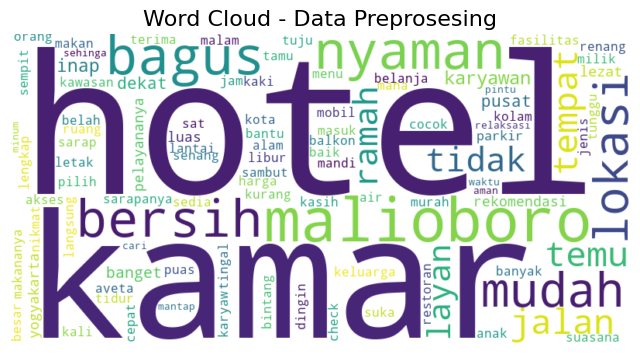

In [57]:
#Visualisasi Word Cloud
text_all = " ".join(
    data['stemming'].apply(lambda x: " ".join(x))
)
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      max_words=100,
                      collocations=False).generate(text_all)
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Data Preprosesing", fontsize=16)
plt.show()


In [58]:
data


,rating,ulasan,label,cleaning,tokenize,normalisasi,lematisasi,stopword,stemming,compare
0,5/5,Hotel yang sangat strategis di Jalan Malioboro...,Negatif,hotel yang sangat strategis di jalan malioboro...,"[hotel, yang, sangat, strategis, di, jalan, ma...","[hotel, yang, sangat, mudah ditemukan, di, jal...","[hotel, yang, sangat, mudah, temukan, di, jala...","[hotel, mudah, temukan, jalan, malioboro, kary...","[hotel, mudah, temu, jalan, malioboro, karyawa...","[(hotel, hotel), (mudah, mudah), (temukan, tem..."
1,5/5,Lokasi teratas. Di sekitar lokasi hotel banyak...,Positif,lokasi teratas di sekitar lokasi hotel banyak ...,"[lokasi, teratas, di, sekitar, lokasi, hotel, ...","[lokasi, teratas, di, sekitar, lokasi, hotel, ...","[lokasi, teratas, di, sekitar, lokasi, hotel, ...","[lokasi, teratas, lokasi, hotel, banyak, toko,...","[lokasi, atas, lokasi, hotel, banyak, toko, to...","[(lokasi, lokasi), (teratas, atas), (lokasi, l..."
2,2/5,Saya tidak cukup merekomendasikannya. Memesan ...,Negatif,saya tidak cukup merekomendasikanya memesan ka...,"[saya, tidak, cukup, merekomendasikanya, memes...","[saya, tidak, cukup, merekomendasikanya, memes...","[saya, tidak, cukup, merekomendasikanya, memes...","[tidak, merekomendasikanya, memesan, kamar, pr...","[tidak, merekomendasikanya, mes, kamar, premie...","[(tidak, tidak), (merekomendasikanya, merekome..."
3,5/5,Menginap 2 hari 2 malam bersama istri dan anak...,Positif,menginap hari malam bersama istri dan anak pua...,"[menginap, hari, malam, bersama, istri, dan, a...","[menginap, hari, malam, bersama, istri, dan, a...","[menginap, hari, malam, bersama, istri, dan, a...","[menginap, malam, istri, anak, puas, banget, n...","[inap, malam, istri, anak, puas, banget, nyama...","[(menginap, inap), (malam, malam), (istri, ist..."
4,2/5,Saya memberikan ini 2 bintang sebelum saya mem...,Negatif,saya memberikan ini bintang sebelum saya memas...,"[saya, memberikan, ini, bintang, sebelum, saya...","[saya, memberikan, ini, bintang, sebelum, saya...","[saya, memberikan, ini, bintang, sebelum, saya...","[bintang, memasuki, ruangan, ruangan, jam, sor...","[bintang, pasuk, ruang, ruang, jam, sore, tang...","[(bintang, bintang), (memasuki, pasuk), (ruang..."
...,...,...,...,...,...,...,...,...,...,...
2258,5/5,"Bagus, menarik",Positif,bagus menarik,"[bagus, menarik]","[bagus, menarik]","[bagus, menarik]","[bagus, menarik]","[bagus, tarik]","[(bagus, bagus), (menarik, tarik)]"
2259,5/5,Semoga beruntung ????,Negatif,semoga beruntung,"[semoga, beruntung]","[semoga, beruntung]","[semoga, beruntung]","[semoga, beruntung]","[moga, untung]","[(semoga, moga), (beruntung, untung)]"
2260,4/5,Layanan ??????,Negatif,layanan,[layanan],[layanan],[layanan],[layanan],[layan],"[(layanan, layan)]"
2261,1/5,Limbah..,Negatif,limbah,[limbah],[limbah],[limbah],[limbah],[limbah],"[(limbah, limbah)]"


In [59]:
persen_nan = data['stemming'].isna().mean() * 100
print(f"Missing value kolom stemming: {persen_nan:.2f}%")


Missing value kolom stemming: 0.00%


In [60]:
data_empty = data[
    (data['lematisasi'].apply(lambda x: len(x)==0)) |
    (data['stopword'].apply(lambda x: len(x)==0)) |
    (data['stemming'].apply(lambda x: len(x)==0))
]
print("Baris Bermasalah")
print(data_empty.head())
print("Minimal panjang lematisasi :", data['lematisasi'].apply(len).min())
print("Minimal panjang stopword   :", data['stopword'].apply(len).min())
print("Minimal panjang stemming:", data['stemming'].apply(len).min())


Baris Bermasalah
     rating                            ulasan    label  \
2021    4/5  Hanya apa yang saya inginkan....  Negatif   
2063    5/5           semuanya baik-baik saja  Positif   
2107    3/5                    Baik-baik saja  Positif   
2144    5/5                        luar biasa  Positif   
2151    5/5   Mungkin, entahlah, aaa, mungkin  Negatif   

                          cleaning                            tokenize  \
2021  hanya apa yang saya inginkan  [hanya, apa, yang, saya, inginkan]   
2063       semuanya baik baik saja        [semuanya, baik, baik, saja]   
2107                baik baik saja                  [baik, baik, saja]   
2144                    luar biasa                       [luar, biasa]   
2151    mungkin entahlah a mungkin     [mungkin, entahlah, a, mungkin]   

                             normalisasi                          lematisasi  \
2021  [hanya, apa, yang, saya, inginkan]  [hanya, apa, yang, saya, inginkan]   
2063        [semuanya, baik, 

In [61]:
persen = (len(data_empty) / len(data)) * 100
print(f"Persentase data bermasalah: {persen:.2f}%")


Persentase data bermasalah: 0.44%


In [62]:
print("Index data bermasalah:")
print(data_empty.index.tolist())


Index data bermasalah:
[2021, 2063, 2107, 2144, 2151, 2166, 2174, 2176, 2191, 2255]


In [63]:
total_sebelum_stemming_filter = len(data)
data = data[data['stemming'].apply(lambda x: len(x) > 0)].reset_index(drop=True)
total_setelah_stemming_filter = len(data)


In [64]:
print("Total data awal :", total_sebelum_stemming_filter)
print("Total data akhir:", total_setelah_stemming_filter)
print("Data di-drop    :", total_sebelum_stemming_filter - total_setelah_stemming_filter)


Total data awal : 2263
Total data akhir: 2253
Data di-drop    : 10


**Wordcloud Kata Positif dan Negatif**

In [65]:
df_pos = data[data['label'] == 'Positif']
df_neg = data[data['label'] == 'Negatif']


Kata Positif

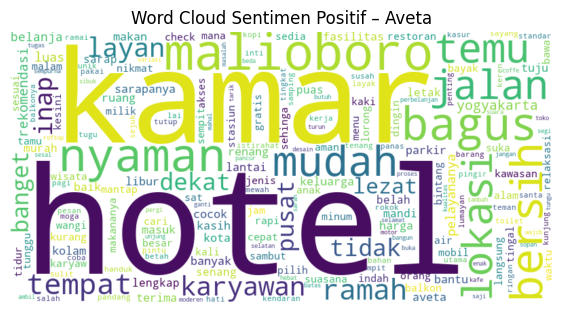

In [66]:
text_pos = " ".join(
    [" ".join(tokens) for tokens in df_pos['stemming']]
)
wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(text_pos)
plt.figure(figsize=(7, 4))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Positif – Aveta")
plt.show()


**Kata Negatif**

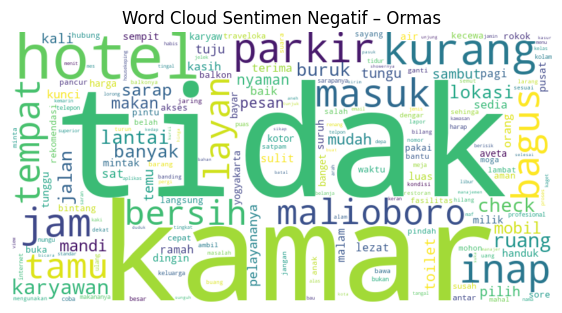

In [67]:
text_pos = " ".join(
    [" ".join(tokens) for tokens in df_neg['stemming']]
)
wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(text_pos)
plt.figure(figsize=(7, 4))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Negatif – Ormas")
plt.show()


In [68]:
# Melihat kembali baris yang telah di tokenisasi
for i, tokens in enumerate(data['stemming']):
    print(f"Review {i+1}:")
    print(tokens, "\n")


Review 1:
['hotel', 'mudah', 'temu', 'jalan', 'malioboro', 'karyawan', 'ramah', 'kamar', 'bersih', 'housekepingnya', 'bagus', 'bersih', 'cepat', 'kurang', 'tidak', 'tempat', 'parkir', 'batas', 'tugas', 'parkir', 'butuh', 'kunci', 'buat', 'tidak', 'nyaman', 'kamar', 'mandi', 'tidak', 'lengkap', 'hand', 'pancur', 'bawa', 'bayi', 'susah', 'mandi', 'showernya', 'atap', 'sarapanya', 'variasi', 'lezat', 'kurang', 'turut', 'tidak', 'bagus', 'moga', 'tingkat', 'ruanganya', 'tidak', 'kedap', 'udara', 'tari', 'kursi', 'kamar', 'belah', 'moga', 'baik', 'hotel', 'rekomendasi', 'coba', 'moga', 'layan', 'kebersihanya', 'jaga'] 

Review 2:
['lokasi', 'atas', 'lokasi', 'hotel', 'banyak', 'toko', 'toko', 'jual', 'barang', 'toko', 'ruang', 'jenis', 'kamar', 'luas', 'bersih', 'wangi', 'dispenser', 'air', 'minum', 'sedia', 'jenis', 'kamar', 'keluarga', 'tidak', 'susah', 'beli', 'air', 'minum'] 

Review 3:
['tidak', 'merekomendasikanya', 'mes', 'kamar', 'premier', 'link', 'aveta', 'hotel', 'tidak', 'sarap'

In [69]:
data['jumlah_kata'] = data['stemming'].apply(len)


In [70]:
data[['stemming', 'jumlah_kata']].head()


,stemming,jumlah_kata
0,"[hotel, mudah, temu, jalan, malioboro, karyawa...",63
1,"[lokasi, atas, lokasi, hotel, banyak, toko, to...",28
2,"[tidak, merekomendasikanya, mes, kamar, premie...",60
3,"[inap, malam, istri, anak, puas, banget, nyama...",36
4,"[bintang, pasuk, ruang, ruang, jam, sore, tang...",62


In [71]:
print(data['jumlah_kata'].describe())


count    2253.000000
mean       13.385708
std        16.742987
min         1.000000
25%         5.000000
50%         8.000000
75%        15.000000
max       192.000000
Name: jumlah_kata, dtype: float64


In [72]:
print("Minimal :", data['jumlah_kata'].min())
print("Maksimal:", data['jumlah_kata'].max())
print("Rata-rata:", data['jumlah_kata'].mean())


Minimal : 1
Maksimal: 192
Rata-rata: 13.385707944962272


In [75]:
total_sebelum_jumlah_filter = len(data)
# Tanpa filter asimetris berdasarkan label (Positif<10 kata)

data = data[data['jumlah_kata'].fillna(0) > 1].copy()
# Data dipertahankan agar distribusi kelas tidak bias karena aturan khusus per label
data = data.reset_index(drop=True)
total_setelah_jumlah_filter = len(data)


In [78]:
label_sebelum = data['label'].value_counts()

data_filtered = data[data['jumlah_kata'].fillna(0) > 1].copy()
label_sesudah = data_filtered['label'].value_counts()

print("Sebelum drop:")
print(label_sebelum)

print("\nSesudah drop:")
print(label_sesudah)


Sebelum drop:
label
Positif    1992
Negatif     187
Name: count, dtype: int64

Sesudah drop:
label
Positif    1992
Negatif     187
Name: count, dtype: int64


In [79]:
print("Jumlah data di-drop:",
      total_sebelum_jumlah_filter - total_setelah_jumlah_filter)


Jumlah data di-drop: 74


In [81]:
data_awal = data.copy()
total_awal_dua_label = len(data_awal)

data_stemming_ok = data_awal[data_awal['stemming'].fillna('').str.strip() != ''].copy()
total_setelah_stemming_filter = len(data_stemming_ok)

data_filtered = data_stemming_ok[data_stemming_ok['jumlah_kata'].fillna(0) > 1].copy()
total_setelah_jumlah_filter = len(data_filtered)

data = data_filtered.reset_index(drop=True)
total_final_model = len(data)

audit_ringkas = pd.DataFrame([
    {"tahap": "Awal dua_label", "jumlah_data": total_awal_dua_label},
    {"tahap": "Setelah drop empty stemming", "jumlah_data": total_setelah_stemming_filter},
    {"tahap": "Setelah drop dokumen 1 kata", "jumlah_data": total_setelah_jumlah_filter},
    {"tahap": "Final dipakai model", "jumlah_data": total_final_model},
])

audit_ringkas["drop_dari_tahap_sebelumnya"] = (
    audit_ringkas["jumlah_data"].shift(1) - audit_ringkas["jumlah_data"]
).fillna(0).astype(int)

audit_ringkas


,tahap,jumlah_data,drop_dari_tahap_sebelumnya
0,Awal dua_label,2179,0
1,Setelah drop empty stemming,2179,0
2,Setelah drop dokumen 1 kata,2179,0
3,Final dipakai model,2179,0


In [82]:
data

,rating,ulasan,label,cleaning,tokenize,normalisasi,lematisasi,stopword,stemming,compare,jumlah_kata
0,5/5,Hotel yang sangat strategis di Jalan Malioboro...,Negatif,hotel yang sangat strategis di jalan malioboro...,"[hotel, yang, sangat, strategis, di, jalan, ma...","[hotel, yang, sangat, mudah ditemukan, di, jal...","[hotel, yang, sangat, mudah, temukan, di, jala...","[hotel, mudah, temukan, jalan, malioboro, kary...","[hotel, mudah, temu, jalan, malioboro, karyawa...","[(hotel, hotel), (mudah, mudah), (temukan, tem...",63
1,5/5,Lokasi teratas. Di sekitar lokasi hotel banyak...,Positif,lokasi teratas di sekitar lokasi hotel banyak ...,"[lokasi, teratas, di, sekitar, lokasi, hotel, ...","[lokasi, teratas, di, sekitar, lokasi, hotel, ...","[lokasi, teratas, di, sekitar, lokasi, hotel, ...","[lokasi, teratas, lokasi, hotel, banyak, toko,...","[lokasi, atas, lokasi, hotel, banyak, toko, to...","[(lokasi, lokasi), (teratas, atas), (lokasi, l...",28
2,2/5,Saya tidak cukup merekomendasikannya. Memesan ...,Negatif,saya tidak cukup merekomendasikanya memesan ka...,"[saya, tidak, cukup, merekomendasikanya, memes...","[saya, tidak, cukup, merekomendasikanya, memes...","[saya, tidak, cukup, merekomendasikanya, memes...","[tidak, merekomendasikanya, memesan, kamar, pr...","[tidak, merekomendasikanya, mes, kamar, premie...","[(tidak, tidak), (merekomendasikanya, merekome...",60
3,5/5,Menginap 2 hari 2 malam bersama istri dan anak...,Positif,menginap hari malam bersama istri dan anak pua...,"[menginap, hari, malam, bersama, istri, dan, a...","[menginap, hari, malam, bersama, istri, dan, a...","[menginap, hari, malam, bersama, istri, dan, a...","[menginap, malam, istri, anak, puas, banget, n...","[inap, malam, istri, anak, puas, banget, nyama...","[(menginap, inap), (malam, malam), (istri, ist...",36
4,2/5,Saya memberikan ini 2 bintang sebelum saya mem...,Negatif,saya memberikan ini bintang sebelum saya memas...,"[saya, memberikan, ini, bintang, sebelum, saya...","[saya, memberikan, ini, bintang, sebelum, saya...","[saya, memberikan, ini, bintang, sebelum, saya...","[bintang, memasuki, ruangan, ruangan, jam, sor...","[bintang, pasuk, ruang, ruang, jam, sore, tang...","[(bintang, bintang), (memasuki, pasuk), (ruang...",62
...,...,...,...,...,...,...,...,...,...,...,...
2174,4/5,"Kerja bagus, sangat nyaman",Positif,kerja bagus sangat nyaman,"[kerja, bagus, sangat, nyaman]","[kerja, bagus, sangat, nyaman]","[kerja, bagus, sangat, nyaman]","[kerja, bagus, nyaman]","[kerja, bagus, nyaman]","[(kerja, kerja), (bagus, bagus), (nyaman, nyam...",3
2175,4/5,bagus dan nyaman juga,Positif,bagus dan nyaman juga,"[bagus, dan, nyaman, juga]","[bagus, dan, nyaman, juga]","[bagus, dan, nyaman, juga]","[bagus, nyaman]","[bagus, nyaman]","[(bagus, bagus), (nyaman, nyaman)]",2
2176,5/5,staf yang ramah dan ramah,Positif,staf yang ramah dan ramah,"[staf, yang, ramah, dan, ramah]","[karyawan, yang, ramah, dan, ramah]","[karyawan, yang, ramah, dan, ramah]","[karyawan, ramah, ramah]","[karyawan, ramah, ramah]","[(karyawan, karyawan), (ramah, ramah), (ramah,...",3
2177,5/5,"Bagus, menarik",Positif,bagus menarik,"[bagus, menarik]","[bagus, menarik]","[bagus, menarik]","[bagus, menarik]","[bagus, tarik]","[(bagus, bagus), (menarik, tarik)]",2


In [ ]:
# # Simpan hasil teks preprosesing
# data.to_csv("data/audit_tr/hasil_preprosesing_aveta_tr.csv", index=False, encoding='utf-8-sig')


# TF-IDF FRECUENCY

In [ ]:
# Konsisten: gunakan hasil preprocessing in-memory
from pathlib import Path
base = Path.cwd()
if (base / 'analisis' / 'data').exists():
    base = base / 'analisis'
elif not (base / 'data').exists() and (base.parent / 'analisis' / 'data').exists():
    base = base.parent / 'analisis'
elif not (base / 'data').exists() and (base.parent / 'data').exists():
    base = base.parent

df = pd.read_csv(base / 'data' / 'prosses' / 'hasil_preprosesing_aveta_tr.csv')
print(f"Total data: {len(df)}")
df.head()


Total data: 2179


,rating,ulasan,label,cleaning,tokenize,normalisasi,lematisasi,stopword,stemming,compare,jumlah_kata
0,5/5,Hotel yang sangat strategis di Jalan Malioboro...,Negatif,hotel yang sangat strategis di jalan malioboro...,"['hotel', 'yang', 'sangat', 'strategis', 'di',...","['hotel', 'yang', 'sangat', 'mudah ditemukan',...","['hotel', 'yang', 'sangat', 'mudah', 'temukan'...","['hotel', 'mudah', 'temukan', 'jalan', 'maliob...","['hotel', 'mudah', 'temu', 'jalan', 'malioboro...","[('hotel', 'hotel'), ('mudah', 'mudah'), ('tem...",63
1,5/5,Lokasi teratas. Di sekitar lokasi hotel banyak...,Positif,lokasi teratas di sekitar lokasi hotel banyak ...,"['lokasi', 'teratas', 'di', 'sekitar', 'lokasi...","['lokasi', 'teratas', 'di', 'sekitar', 'lokasi...","['lokasi', 'teratas', 'di', 'sekitar', 'lokasi...","['lokasi', 'teratas', 'lokasi', 'hotel', 'bany...","['lokasi', 'atas', 'lokasi', 'hotel', 'banyak'...","[('lokasi', 'lokasi'), ('teratas', 'atas'), ('...",28
2,2/5,Saya tidak cukup merekomendasikannya. Memesan ...,Negatif,saya tidak cukup merekomendasikanya memesan ka...,"['saya', 'tidak', 'cukup', 'merekomendasikanya...","['saya', 'tidak', 'cukup', 'merekomendasikanya...","['saya', 'tidak', 'cukup', 'merekomendasikanya...","['tidak', 'merekomendasikanya', 'memesan', 'ka...","['tidak', 'merekomendasikanya', 'mes', 'kamar'...","[('tidak', 'tidak'), ('merekomendasikanya', 'm...",60
3,5/5,Menginap 2 hari 2 malam bersama istri dan anak...,Positif,menginap hari malam bersama istri dan anak pua...,"['menginap', 'hari', 'malam', 'bersama', 'istr...","['menginap', 'hari', 'malam', 'bersama', 'istr...","['menginap', 'hari', 'malam', 'bersama', 'istr...","['menginap', 'malam', 'istri', 'anak', 'puas',...","['inap', 'malam', 'istri', 'anak', 'puas', 'ba...","[('menginap', 'inap'), ('malam', 'malam'), ('i...",36
4,2/5,Saya memberikan ini 2 bintang sebelum saya mem...,Negatif,saya memberikan ini bintang sebelum saya memas...,"['saya', 'memberikan', 'ini', 'bintang', 'sebe...","['saya', 'memberikan', 'ini', 'bintang', 'sebe...","['saya', 'memberikan', 'ini', 'bintang', 'sebe...","['bintang', 'memasuki', 'ruangan', 'ruangan', ...","['bintang', 'pasuk', 'ruang', 'ruang', 'jam', ...","[('bintang', 'bintang'), ('memasuki', 'pasuk')...",62


In [85]:
# Melihat kembali baris yang telah di tokenisasi
for i, tokens in enumerate(df['stemming']):
    print(f"Review {i+1}:")
    print(tokens, "\n")


Review 1:
['hotel', 'mudah', 'temu', 'jalan', 'malioboro', 'karyawan', 'ramah', 'kamar', 'bersih', 'housekepingnya', 'bagus', 'bersih', 'cepat', 'kurang', 'tidak', 'tempat', 'parkir', 'batas', 'tugas', 'parkir', 'butuh', 'kunci', 'buat', 'tidak', 'nyaman', 'kamar', 'mandi', 'tidak', 'lengkap', 'hand', 'pancur', 'bawa', 'bayi', 'susah', 'mandi', 'showernya', 'atap', 'sarapanya', 'variasi', 'lezat', 'kurang', 'turut', 'tidak', 'bagus', 'moga', 'tingkat', 'ruanganya', 'tidak', 'kedap', 'udara', 'tari', 'kursi', 'kamar', 'belah', 'moga', 'baik', 'hotel', 'rekomendasi', 'coba', 'moga', 'layan', 'kebersihanya', 'jaga'] 

Review 2:
['lokasi', 'atas', 'lokasi', 'hotel', 'banyak', 'toko', 'toko', 'jual', 'barang', 'toko', 'ruang', 'jenis', 'kamar', 'luas', 'bersih', 'wangi', 'dispenser', 'air', 'minum', 'sedia', 'jenis', 'kamar', 'keluarga', 'tidak', 'susah', 'beli', 'air', 'minum'] 

Review 3:
['tidak', 'merekomendasikanya', 'mes', 'kamar', 'premier', 'link', 'aveta', 'hotel', 'tidak', 'sarap'

In [86]:
# Cek Missing Value pada data hasil preprosesing
missing = df.isna().sum().to_frame('missing')
print(missing)

             missing
rating             0
ulasan             0
label              0
cleaning           0
tokenize           0
normalisasi        0
lematisasi         0
stopword           0
stemming           0
compare            0
jumlah_kata        0


In [87]:
df['stemming'] = df['stemming'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


In [88]:
index = 0
for i in df['stemming']:
  if index == 5:
    break
  print(type(i))
  index += 1


<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


**Perhitungan TF**

In [89]:
def calc_TF(document):
    # Step 1: Count term occurrences
    tf_dict = {}
    for term in document:
        if term in tf_dict:
            tf_dict[term] += 1
        else:
            tf_dict[term] = 1

    # Step 2: Normalize by the total number of terms (TF calculation)
    for term in tf_dict:
        tf_dict[term] = tf_dict[term] / len(document)

    return tf_dict

# Apply TF calculation to each list of tokens in 'tekslist'
df["tf"] = df["stemming"].apply(calc_TF)

# Display the first few TF dictionaries
df["tf"].head()


0    {'hotel': 0.031746031746031744, 'mudah': 0.015...
1    {'lokasi': 0.07142857142857142, 'atas': 0.0357...
2    {'tidak': 0.1, 'merekomendasikanya': 0.0166666...
3    {'inap': 0.027777777777777776, 'malam': 0.0277...
4    {'bintang': 0.016129032258064516, 'pasuk': 0.0...
Name: tf, dtype: object

In [90]:
#Displaying a Document’s TF Values
#Prints all terms and their Term Frequency (TF) values for a specific document (here, document index = 1)
index = 5

print("%20s" % "term", "\t", "tf\n")
for key in df["tf"][index]:
    print('%20s' % key, "\t", df["tf"][index][key])


                term 	 tf

              lokasi 	 0.01282051282051282
               mudah 	 0.01282051282051282
                temu 	 0.01282051282051282
              banget 	 0.01282051282051282
                kali 	 0.01282051282051282
              kesini 	 0.01282051282051282
                hati 	 0.02564102564102564
               pintu 	 0.01282051282051282
               masuk 	 0.02564102564102564
              lorong 	 0.01282051282051282
                mpit 	 0.01282051282051282
               dekat 	 0.01282051282051282
                 pos 	 0.01282051282051282
              wisata 	 0.01282051282051282
         pelayananya 	 0.01282051282051282
               ramah 	 0.01282051282051282
            sensitif 	 0.01282051282051282
               bisik 	 0.02564102564102564
               suami 	 0.01282051282051282
               makan 	 0.02564102564102564
             bingung 	 0.01282051282051282
                cari 	 0.01282051282051282
              sendok 	 0.01

**Perhitungan IDF**

In [91]:
#Calculating Document Frequency (DF)
def calc_DF(tfDict):
    count_DF = {}
    for document in tfDict:
        for term in document:
            if term in count_DF:
                count_DF[term] += 1
            else:
                count_DF[term] = 1
    return count_DF

DF = calc_DF(df["tf"])
DF


{'hotel': 913,
 'mudah': 573,
 'temu': 541,
 'jalan': 394,
 'malioboro': 698,
 'karyawan': 356,
 'ramah': 478,
 'kamar': 772,
 'bersih': 619,
 'housekepingnya': 4,
 'bagus': 636,
 'cepat': 81,
 'kurang': 103,
 'tidak': 316,
 'tempat': 475,
 'parkir': 163,
 'batas': 22,
 'tugas': 22,
 'butuh': 18,
 'kunci': 17,
 'buat': 10,
 'nyaman': 702,
 'mandi': 101,
 'lengkap': 103,
 'hand': 1,
 'pancur': 21,
 'bawa': 45,
 'bayi': 4,
 'susah': 43,
 'showernya': 7,
 'atap': 5,
 'sarapanya': 138,
 'variasi': 18,
 'lezat': 276,
 'turut': 9,
 'moga': 31,
 'tingkat': 25,
 'ruanganya': 5,
 'kedap': 12,
 'udara': 3,
 'tari': 1,
 'kursi': 15,
 'belah': 105,
 'baik': 123,
 'rekomendasi': 255,
 'coba': 30,
 'layan': 426,
 'kebersihanya': 8,
 'jaga': 10,
 'lokasi': 590,
 'atas': 7,
 'banyak': 158,
 'toko': 19,
 'jual': 14,
 'barang': 22,
 'ruang': 121,
 'jenis': 57,
 'luas': 227,
 'wangi': 42,
 'dispenser': 7,
 'air': 56,
 'minum': 38,
 'sedia': 57,
 'keluarga': 168,
 'beli': 8,
 'merekomendasikanya': 5,
 'me

In [92]:
#Calculating Inverse Document Frequency (IDF)
n_document = len(df)

def calc_IDF(n_document, DF):
    IDF_dict = {}
    for term in DF:
        IDF_dict[term] = np.log10(n_document / (DF[term] + 1))
    return IDF_dict

IDF = calc_IDF(n_document, DF)


In [93]:
selected_terms = ['aveta', 'nyaman', 'malioboro']

idf_selected = {term: IDF.get(term, 0) for term in selected_terms}
print("Nilai IDF untuk kata ['aveta', 'nyaman', 'malioboro']:")
print(idf_selected)


Nilai IDF untuk kata ['aveta', 'nyaman', 'malioboro']:
{'aveta': np.float64(1.1592802829530862), 'nyaman': np.float64(0.4913019052264317), 'malioboro': np.float64(0.4937800545005742)}


In [94]:
#Calculating TF-IDF
#Purpose:
#Computes the TF-IDF value for each term in each document by multiplying TF and IDF.
def calc_TF_IDF(TF, IDF):
    TF_IDF_dict = {}
    for key in TF:
        if key in IDF:  # add safety check
            TF_IDF_dict[key] = TF[key] * IDF[key]
    return TF_IDF_dict

# Apply properly
df["tf-idf"] = df["tf"].apply(lambda x: calc_TF_IDF(x, IDF))


**Hasil perhitungan TF_IDF**

In [95]:
# Tampilkan nilai TF dan TF-IDF untuk dokumen ke-1
index = 1

print(f'{"Term":<20}\t{"TF":<10}\t{"TF-IDF":<20}')
print('-' * 60)

for term, tfidf_val in df["tf-idf"][index].items():
    tf_val = df["tf"][index].get(term, 0)
    print(f'{term:<20}\t{tf_val:<10.4f}\t{tfidf_val:<20.6f}')


Term                	TF        	TF-IDF              
------------------------------------------------------------
lokasi              	0.0714    	0.040476            
atas                	0.0357    	0.086970            
hotel               	0.0357    	0.013475            
banyak              	0.0357    	0.040602            
toko                	0.1071    	0.218274            
jual                	0.0357    	0.077220            
barang              	0.0357    	0.070590            
ruang               	0.0357    	0.044711            
jenis               	0.0714    	0.112488            
kamar               	0.0714    	0.032148            
luas                	0.0357    	0.035012            
bersih              	0.0357    	0.019495            
wangi               	0.0357    	0.060885            
dispenser           	0.0357    	0.086970            
air                 	0.0714    	0.113027            
minum               	0.0714    	0.124799            
sedia               	0.0357    	0.0562

**Matrik TF-IDF Vectorizer**

In [96]:
# Membuat matriks TF-IDF
# Urutkan kata berdasarkan Document Frequency (descending)
sorted_DF = sorted(DF.items(), key=lambda kv: kv[1], reverse=True)[:30]
unique_terms = [term for term, _ in sorted_DF]

# Fungsi untuk mengonversi TF-IDF dict ke vektor
def calc_TF_IDF_Vec(tfidf_dict):
    vector = [0.0] * len(unique_terms)
    for i, term in enumerate(unique_terms):
        vector[i] = tfidf_dict.get(term, 0.0)
    return vector

# Terapkan fungsi ke setiap dokumen
df["tf_idf_vectoring"] = df["tf-idf"].apply(calc_TF_IDF_Vec)

# Cek hasil
print("Tampilan baris pertama dari matriks tf_idf_vectoring:\n")
print(df["tf_idf_vectoring"].iloc[1])
print("\nUkuran vektor (jumlah fitur):", len(df["tf_idf_vectoring"].iloc[0]))


Tampilan baris pertama dari matriks tf_idf_vectoring:

[np.float64(0.013475394089729436), np.float64(0.032148409737709334), 0.0, 0.0, 0.0, np.float64(0.019495197883857205), np.float64(0.04047641066892859), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.02989992742958943), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.03501151368735006), 0.0, 0.0, np.float64(0.039656090201163646), 0.0, 0.0, 0.0]

Ukuran vektor (jumlah fitur): 30


**Menampilkan hasil ke dalam List**

In [97]:
# Menampilkan top 30 term berdasarkan total TF-IDF
# Konversi kolom TF-IDF vector menjadi array 2D
TF_IDF_Vec_List = np.array(df["tf_idf_vectoring"].to_list())

# Hitung jumlah TF-IDF setiap term di seluruh dokumen
term_sums = TF_IDF_Vec_List.sum(axis=0)

# Buat DataFrame untuk peringkat term
ranking = pd.DataFrame({
    'Term': unique_terms,
    'TF-IDF': term_sums
})
# Urutkan dari nilai tertinggi ke terendah
ranking = ranking.sort_values(by='TF-IDF', ascending=False).reset_index(drop=True)

# Tampilkan top 30 term
print("Top 30 terms berdasarkan total TF-IDF:")
print(ranking.head(100))


Top 30 terms berdasarkan total TF-IDF:
           Term     TF-IDF
0         bagus  54.216049
1        nyaman  53.664974
2        tempat  45.496465
3         hotel  41.413184
4         layan  37.880427
5        bersih  37.707078
6     malioboro  34.125477
7         ramah  33.942069
8         kamar  33.243454
9         mudah  30.751005
10       lokasi  30.326584
11         temu  29.610707
12  rekomendasi  28.855446
13  pelayananya  28.685897
14     karyawan  28.082021
15         inap  27.525529
16        dekat  26.787325
17        jalan  25.921571
18       banget  23.943632
19        tidak  21.024968
20        lezat  20.506804
21       parkir  18.883439
22    fasilitas  18.865364
23        pusat  18.695020
24   yogyakarta  18.664725
25     keluarga  17.934780
26        harga  16.839316
27         luas  15.442122
28        makan  11.920497
29      belanja  11.620207


In [98]:
#Analisis kata penting per dokumen
for i, tfidf_vector in enumerate(TF_IDF_Vec_List[:10]):  # contoh 5 dokumen pertama
    top_indices = tfidf_vector.argsort()[-5:][::-1]  # ambil 5 term tertinggi
    top_terms = [unique_terms[idx] for idx in top_indices]
    print(f"Dokumen {i}: {top_terms}")


Dokumen 0: ['tidak', 'parkir', 'kamar', 'bersih', 'bagus']
Dokumen 1: ['lokasi', 'keluarga', 'luas', 'kamar', 'tidak']
Dokumen 2: ['tidak', 'kamar', 'makan', 'fasilitas', 'lezat']
Dokumen 3: ['parkir', 'banget', 'makan', 'harga', 'tidak']
Dokumen 4: ['kamar', 'harga', 'parkir', 'keluarga', 'fasilitas']
Dokumen 5: ['makan', 'tidak', 'bersih', 'pelayananya', 'banget']
Dokumen 6: ['inap', 'tidak', 'kamar', 'parkir', 'harga']
Dokumen 7: ['makan', 'tidak', 'inap', 'layan', 'ramah']
Dokumen 8: ['inap', 'keluarga', 'fasilitas', 'luas', 'rekomendasi']
Dokumen 9: ['tidak', 'karyawan', 'yogyakarta', 'hotel', 'ramah']


In [99]:
dict_label_sentimen = {}
label_classes = []
index = 0
for label in df['label']:
  if label not in dict_label_sentimen:
    dict_label_sentimen[label] = index
    label_classes.append(label)
    index += 1


In [100]:
df['encoded'] = df['label'].apply(lambda x: dict_label_sentimen[x])


In [101]:
dict_label_sentimen


{'Negatif': 0, 'Positif': 1}

In [102]:
df

,rating,ulasan,label,cleaning,tokenize,normalisasi,lematisasi,stopword,stemming,compare,jumlah_kata,tf,tf-idf,tf_idf_vectoring,encoded
0,5/5,Hotel yang sangat strategis di Jalan Malioboro...,Negatif,hotel yang sangat strategis di jalan malioboro...,"['hotel', 'yang', 'sangat', 'strategis', 'di',...","['hotel', 'yang', 'sangat', 'mudah ditemukan',...","['hotel', 'yang', 'sangat', 'mudah', 'temukan'...","['hotel', 'mudah', 'temukan', 'jalan', 'maliob...","[hotel, mudah, temu, jalan, malioboro, karyawa...","[('hotel', 'hotel'), ('mudah', 'mudah'), ('tem...",63,"{'hotel': 0.031746031746031744, 'mudah': 0.015...","{'hotel': 0.011978128079759499, 'mudah': 0.009...","[0.011978128079759499, 0.02143227315847289, 0....",0
1,5/5,Lokasi teratas. Di sekitar lokasi hotel banyak...,Positif,lokasi teratas di sekitar lokasi hotel banyak ...,"['lokasi', 'teratas', 'di', 'sekitar', 'lokasi...","['lokasi', 'teratas', 'di', 'sekitar', 'lokasi...","['lokasi', 'teratas', 'di', 'sekitar', 'lokasi...","['lokasi', 'teratas', 'lokasi', 'hotel', 'bany...","[lokasi, atas, lokasi, hotel, banyak, toko, to...","[('lokasi', 'lokasi'), ('teratas', 'atas'), ('...",28,"{'lokasi': 0.07142857142857142, 'atas': 0.0357...","{'lokasi': 0.04047641066892859, 'atas': 0.0869...","[0.013475394089729436, 0.032148409737709334, 0...",1
2,2/5,Saya tidak cukup merekomendasikannya. Memesan ...,Negatif,saya tidak cukup merekomendasikanya memesan ka...,"['saya', 'tidak', 'cukup', 'merekomendasikanya...","['saya', 'tidak', 'cukup', 'merekomendasikanya...","['saya', 'tidak', 'cukup', 'merekomendasikanya...","['tidak', 'merekomendasikanya', 'memesan', 'ka...","[tidak, merekomendasikanya, mes, kamar, premie...","[('tidak', 'tidak'), ('merekomendasikanya', 'm...",60,"{'tidak': 0.1, 'merekomendasikanya': 0.0166666...","{'tidak': 0.08371979680285041, 'merekomendasik...","[0.012577034483747473, 0.030005182421862047, 0...",0
3,5/5,Menginap 2 hari 2 malam bersama istri dan anak...,Positif,menginap hari malam bersama istri dan anak pua...,"['menginap', 'hari', 'malam', 'bersama', 'istr...","['menginap', 'hari', 'malam', 'bersama', 'istr...","['menginap', 'hari', 'malam', 'bersama', 'istr...","['menginap', 'malam', 'istri', 'anak', 'puas',...","[inap, malam, istri, anak, puas, banget, nyama...","[('menginap', 'inap'), ('malam', 'malam'), ('i...",36,"{'inap': 0.027777777777777776, 'malam': 0.0277...","{'inap': 0.021720964707749122, 'malam': 0.0377...","[0.0, 0.012502159342442518, 0.0136472751451786...",1
4,2/5,Saya memberikan ini 2 bintang sebelum saya mem...,Negatif,saya memberikan ini bintang sebelum saya memas...,"['saya', 'memberikan', 'ini', 'bintang', 'sebe...","['saya', 'memberikan', 'ini', 'bintang', 'sebe...","['saya', 'memberikan', 'ini', 'bintang', 'sebe...","['bintang', 'memasuki', 'ruangan', 'ruangan', ...","[bintang, pasuk, ruang, ruang, jam, sore, tang...","[('bintang', 'bintang'), ('memasuki', 'pasuk')...",62,"{'bintang': 0.016129032258064516, 'pasuk': 0.0...","{'bintang': 0.02460232054199032, 'pasuk': 0.04...","[0.0, 0.0145186366557397, 0.0, 0.0, 0.0, 0.0, ...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2174,4/5,"Kerja bagus, sangat nyaman",Positif,kerja bagus sangat nyaman,"['kerja', 'bagus', 'sangat', 'nyaman']","['kerja', 'bagus', 'sangat', 'nyaman']","['kerja', 'bagus', 'sangat', 'nyaman']","['kerja', 'bagus', 'nyaman']","[kerja, bagus, nyaman]","[('kerja', 'kerja'), ('bagus', 'bagus'), ('nya...",3,"{'kerja': 0.3333333333333333, 'bagus': 0.33333...","{'kerja': 0.6720126451707787, 'bagus': 0.17803...","[0.0, 0.0, 0.16376730174214388, 0.0, 0.1780392...",1
2175,4/5,bagus dan nyaman juga,Positif,bagus dan nyaman juga,"['bagus', 'dan', 'nyaman', 'juga']","['bagus', 'dan', 'nyaman', 'juga']","['bagus', 'dan', 'nyaman', 'juga']","['bagus', 'nyaman']","[bagus, nyaman]","[('bagus', 'bagus'), ('nyaman', 'nyaman')]",2,"{'bagus': 0.5, 'nyaman': 0.5}","{'bagus': 0.2670588989554526, 'nyaman': 0.2456...","[0.0, 0.0, 0.24565095261321584, 0.0, 0.2670588...",1
2176,5

In [ ]:
# df.to_csv("data/audit_tr/final_aveta_tr.csv", index = False)


# **Klasifikasi Model**

In [243]:
from pathlib import Path
import pandas as pd
import ast

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
csv_path = None

for candidate in candidates:
    direct = candidate / 'data' / 'prosses' / 'stemming.csv'
    nested = candidate / 'analisis' / 'data' / 'prosses' / 'stemming.csv'
    if direct.exists():
        csv_path = direct
        break
    if nested.exists():
        csv_path = nested
        break

if csv_path is None:
    raise FileNotFoundError('File stemming.csv tidak ditemukan dari direktori kerja saat ini.')

data = pd.read_csv(csv_path, sep=';')
data['stemming'] = data['stemming'].apply(ast.literal_eval)

ACTIVE_PROCESSED_DATASET = str(csv_path)
print(f"Processed dataset aktif: {csv_path}")
print(f"Total data: {len(data)}")
data.head()


Processed dataset aktif: D:\PROYEK TUGAS AKHIR\APP TA\analisis\data\prosses\stemming.csv
Total data: 2175


,stemming,label
0,"[hotel, mudah, temu, jalan, malioboro, karyawa...",Negatif
1,"[lokasi, atas, lokasi, hotel, banyak, toko, to...",Positif
2,"[pengalaman, menginap, tidak, senang, menginap...",Negatif
3,"[lokasi, mudah, temu, makan, lengkap, variasi,...",Positif
4,"[anak, nikmat, menginap, hotel, kolam, renang,...",Positif


In [244]:
dict_label_sentimen = {}
label_classes = []
index = 0
for label in data['label']:
  if label not in dict_label_sentimen:
    dict_label_sentimen[label] = index
    label_classes.append(label)
    index += 1
data['encoded'] = data['label'].apply(lambda x: dict_label_sentimen[x])
dict_label_sentimen

{'Negatif': 0, 'Positif': 1}

In [245]:
# Cek ulasan negatif pada tabel steamming semuanya
negatif = data[data['label'] == 'Negatif'][['stemming', 'label', 'encoded']]
data_negatif = data[data['label'] == 'Negatif']
print(f"Total data negatif: {len(data_negatif)}")
print(negatif.head())


Total data negatif: 185
                                             stemming    label  encoded
0   [hotel, mudah, temu, jalan, malioboro, karyawa...  Negatif        0
2   [pengalaman, menginap, tidak, senang, menginap...  Negatif        0
18  [listrik, padam, menit, tidak, jelas, hotel, l...  Negatif        0
39  [hotel, bagus, menu, sarapan, kamar, lokasi, m...  Negatif        0
40                   [rencana, tingal, parkir, mobil]  Negatif        0


In [154]:
# # Data Steamming
# df_stemming = data[['stemming', 'label']].copy()
# df_stemming.to_csv('data/processed/stemming.csv', index=False, sep=';')
# print("Data stemming disimpan ke 'data/processed/stemming.csv'")


In [246]:
total_negatif = len(data[data['label'] == "Negatif"])
total_positif = len(data[data['label'] == "Positif"])


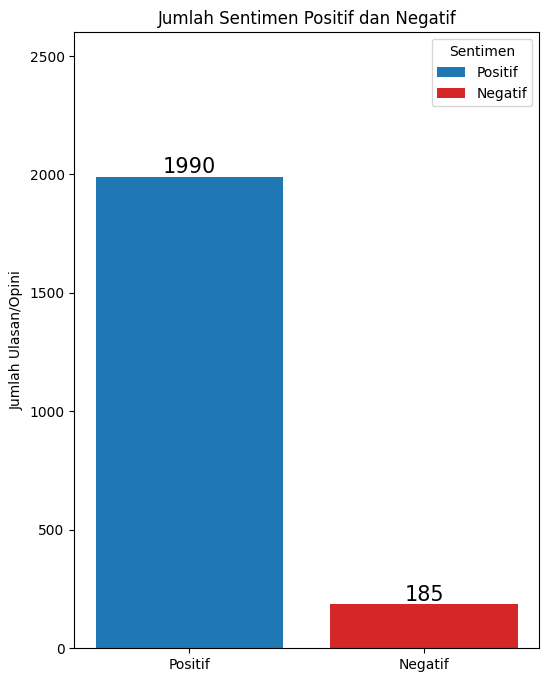

In [247]:
fig, ax = plt.subplots(figsize=(6,8))
fruits = ['Positif', 'Negatif']
counts = [total_positif, total_negatif]
bar_labels = fruits
bar_colors = ['tab:blue', 'tab:red']
bar_container = ax.bar(fruits, counts, label=bar_labels, color=bar_colors)
ax.bar_label(bar_container, size = 15)
ax.set_ylim(0, 2600)
ax.set_ylabel('Jumlah Ulasan/Opini')
ax.set_title('Jumlah Sentimen Positif dan Negatif')
ax.legend(title='Sentimen')
plt.show()


Split Data

In [249]:
import ast

def safe_eval(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []


In [250]:
data['stemming'] = data['stemming'].apply(safe_eval)

if 'encoded' not in data.columns:
    data['encoded'] = data['label'].map({'Negatif': 0, 'Positif': 1})

X = data['stemming']
y = data['encoded'].astype(int)

print(f"Data modeling siap: {len(data)} baris")
print(f"Sumber modeling: {ACTIVE_PROCESSED_DATASET}")


Data modeling siap: 2175 baris
Sumber modeling: D:\PROYEK TUGAS AKHIR\APP TA\analisis\data\prosses\stemming.csv


In [251]:
X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Jumlah data train: {len(X_train_tokens)} | test: {len(X_test_tokens)}')


Jumlah data train: 1740 | test: 435


In [252]:
X


0       [hotel, mudah, temu, jalan, malioboro, karyawa...
1       [lokasi, atas, lokasi, hotel, banyak, toko, to...
2       [pengalaman, menginap, tidak, senang, menginap...
3       [lokasi, mudah, temu, makan, lengkap, variasi,...
4       [anak, nikmat, menginap, hotel, kolam, renang,...
                              ...                        
2170                               [kerja, bagus, nyaman]
2171                                      [bagus, nyaman]
2172                             [karyawan, ramah, ramah]
2173                                       [bagus, tarik]
2174             [semoga, untung, menginap, hotel, jelek]
Name: stemming, Length: 2175, dtype: object

In [253]:
sentiment_counts = {
    'Positif': np.array([0, 0]),
    'Negatif': np.array([0, 0])
}


In [254]:
# Pastikan split tersedia meskipun cell ini dijalankan terpisah
if 'X_train_tokens' not in globals() or 'X_test_tokens' not in globals() or 'y_train' not in globals() or 'y_test' not in globals():
    X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

# Reset counts agar aman jika cell dijalankan berulang
sentiment_counts = {
    'Positif': np.array([0, 0]),
    'Negatif': np.array([0, 0])
}

label_map = {0: 'Negatif', 1: 'Positif'}

for label in y_train:
    sentiment_counts[label_map[int(label)]][0] += 1

for label in y_test:
    sentiment_counts[label_map[int(label)]][1] += 1


In [255]:
pd.DataFrame(
    sentiment_counts,
    index=['Data Latih', 'Data Uji']
).T

,Data Latih,Data Uji
Positif,1592,398
Negatif,148,37


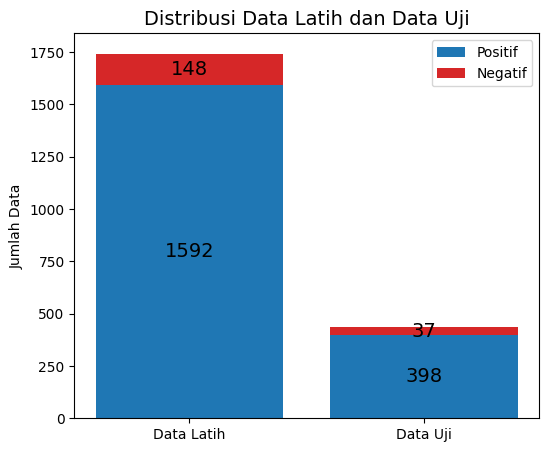

In [256]:
fig, ax = plt.subplots(figsize=(6, 5))
bottom = np.zeros(2)
data_horizontal = ('Data Latih', 'Data Uji')
bar_colors = {
    'Positif': 'tab:blue',
    'Negatif': 'tab:red'
}
for label in ['Positif', 'Negatif']:
    jumlah_sentimen = sentiment_counts[label]
    p = ax.bar(
        data_horizontal,
        jumlah_sentimen,
        bottom=bottom,
        label=label,
        color=bar_colors[label],
        width=0.8
    )
    ax.bar_label(
        p,
        labels=[f"{v:.0f}" for v in jumlah_sentimen],
        label_type='center',
        color='black',
        size=14
    )
    bottom += jumlah_sentimen
ax.set_title('Distribusi Data Latih dan Data Uji', fontsize=14)
ax.set_ylabel('Jumlah Data')
ax.legend()
ax.set_ylim(0, bottom.max() + 100)
plt.show()


# Ekstrasi Fitur (TF-IDF)

In [258]:
# Gunakan hasil split yang sudah ada; buat ulang hanya jika perlu
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=2,
    sublinear_tf=True,
    norm='l2'
)

print('TF-IDF siap dibangun dari dataset aktif.')


TF-IDF siap dibangun dari dataset aktif.


In [259]:
tfidf.fit(X_train_tokens)
# print('TF-IDF siap. Jumlah data latih:', len(X_train_tokens))


,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,False
,preprocessor,<function <la...0022E5EE07880>
,tokenizer,<function <la...0022E5EFBE700>
,analyzer,'word'
,stop_words,None
,token_pattern,None
,ngram_range,"(1, ...)"


In [260]:
tfidf.idf_


array([7.36360265, 6.51630479, 7.36360265, ..., 5.97730829, 7.36360265,
       7.36360265], shape=(5123,))

In [261]:
tfidf.get_feature_names_out()[:200]


array(['abai', 'acara', 'acara karyawan', 'ada', 'agam', 'agam makan',
       'ah', 'air', 'air kamar', 'air kamar mandi', 'air mineral',
       'air mineral lorong', 'air minum', 'air minum ambil', 'air panas',
       'air panas fungsi', 'air panas lancar', 'air pancur', 'air toilet',
       'air ukur', 'air ukur ml', 'air wudhu', 'ajak', 'ajak anak',
       'akal', 'akibat', 'akomodasi', 'akses', 'akses dekat',
       'akses hotel', 'akses jalan', 'akses malioboro', 'akses mana',
       'akses mana dekat', 'akses mana mudah', 'akses masuk',
       'akses masuk kurang', 'akses mobil', 'akses mudah',
       'akses mudah dekat', 'akses mudah layan', 'akses mudah nyaman',
       'akses parkir', 'akses pintu', 'akses ruang', 'akses ruang tunggu',
       'akses stasiun', 'akses sulit', 'akses tempat',
       'akses tempat parkir', 'alamat', 'alami', 'alangkah',
       'alangkah baik', 'alas', 'alat', 'alfamart', 'alfamart tidak',
       'alhamdulilah', 'alun', 'aman', 'aman bantu', 'aman h

In [262]:
tfidf.vocabulary_


{'temu': 4620,
 'makan': 2735,
 'mudah': 3229,
 'dekat': 888,
 'tempat': 4523,
 'hotel': 1168,
 'jalan': 1467,
 'malioboro': 2812,
 'temu makan': 4677,
 'mudah dekat': 3236,
 'dekat tempat': 926,
 'tempat hotel': 4549,
 'hotel jalan': 1253,
 'jalan malioboro': 1498,
 'mudah dekat tempat': 3237,
 'hotel jalan malioboro': 1255,
 'layan': 2338,
 'bagus': 150,
 'lokasi': 2611,
 'buka': 745,
 'pintu': 3681,
 'langsung': 2261,
 'belanja': 505,
 'pusat': 3748,
 'layan bagus': 2341,
 'bagus lokasi': 211,
 'lokasi mudah': 2643,
 'mudah temu': 3248,
 'buka pintu': 746,
 'pintu langsung': 3686,
 'langsung jalan': 2266,
 'malioboro belanja': 2828,
 'belanja dekat': 511,
 'dekat malioboro': 903,
 'malioboro pusat': 2908,
 'pusat belanja': 3749,
 'layan bagus lokasi': 2350,
 'bagus lokasi mudah': 214,
 'lokasi mudah temu': 2645,
 'buka pintu langsung': 747,
 'langsung jalan malioboro': 2267,
 'jalan malioboro belanja': 1503,
 'dekat malioboro pusat': 911,
 'malioboro pusat belanja': 2909,
 'nyaman':

In [263]:
print(len(tfidf.vocabulary_))


5123


In [264]:
X_train_tfidf = tfidf.transform(X_train_tokens)
X_test_tfidf = tfidf.transform(X_test_tokens)

print('Shape X_train_tfidf:', X_train_tfidf.shape)
print('Shape X_test_tfidf:', X_test_tfidf.shape)


Shape X_train_tfidf: (1740, 5123)
Shape X_test_tfidf: (435, 5123)


In [266]:
from sklearn.utils import resample
import numpy as np

# Upsample kelas minoritas (training saja) agar lebih seimbang
# Catatan: gunakan X_train hasil TF-IDF (sparse) + y_train asli

def upsample_minority_sparse(X, y, random_state=42):
    y_arr = np.asarray(y)
    classes, counts = np.unique(y_arr, return_counts=True)
    if len(classes) < 2:
        return X, y_arr
    maj_class = classes[np.argmax(counts)]
    min_class = classes[np.argmin(counts)]
    idx_maj = np.where(y_arr == maj_class)[0]
    idx_min = np.where(y_arr == min_class)[0]
    if len(idx_min) == 0 or len(idx_maj) == 0:
        return X, y_arr
    idx_min_up = resample(
        idx_min,
        replace=True,
        n_samples=len(idx_maj),
        random_state=random_state
    )
    idx_bal = np.concatenate([idx_maj, idx_min_up])
    rng = np.random.RandomState(random_state)
    rng.shuffle(idx_bal)
    return X[idx_bal], y_arr[idx_bal]

X_train_bal, y_train_bal = upsample_minority_sparse(X_train_tfidf, y_train, random_state=42)

print('Distribusi kelas (train asli):', np.bincount(np.asarray(y_train)))
print('Distribusi kelas (train balanced):', np.bincount(np.asarray(y_train_bal)))


Distribusi kelas (train asli): [ 148 1592]
Distribusi kelas (train balanced): [1592 1592]


# Naive Bayes

In [267]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import ComplementNB

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

param_grid = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 10, 1000]
}

grid = GridSearchCV(
    ComplementNB(),
    param_grid,
    cv=5,
    scoring='f1_macro'
)


In [268]:
grid.fit(X_train_bal, y_train_bal)


,estimator,ComplementNB()
,param_grid,"{'alpha': [0.01, 0.05, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.01


In [269]:

nbm = grid.best_estimator_


In [270]:
print("Alpha terbaik:", grid.best_params_)
print("Score terbaik:", grid.best_score_)
print("Best estimator:", grid.best_estimator_)


Alpha terbaik: {'alpha': 0.01}
Score terbaik: 0.9830348899057887
Best estimator: ComplementNB(alpha=0.01)


Traning

TRAINING EVALUATION
Accuracy (Train): 0.9885057471264368

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       148
           1       1.00      0.99      0.99      1592

    accuracy                           0.99      1740
   macro avg       0.94      0.99      0.97      1740
weighted avg       0.99      0.99      0.99      1740



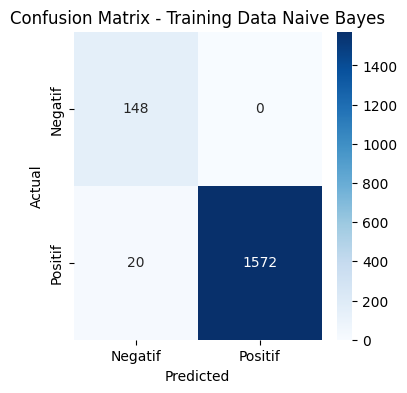

In [271]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, hinge_loss
# Prediksi data testing
print("TRAINING EVALUATION")
y_pred = nbm.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, y_pred)

print("Accuracy (Train):", train_acc)
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred))
#confusing matrix
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Data Naive Bayes")
plt.show()


Testing

TESTING EVALUATION (NAIVE BAYES)
Accuracy  : 0.9402
Precision : 0.9450
Recall    : 0.9402
F1-Score  : 0.9422
Log Loss  : 0.1769
Balanced Acc: 0.8448

Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.63      0.73      0.68        37
     Positif       0.97      0.96      0.97       398

    accuracy                           0.94       435
   macro avg       0.80      0.84      0.82       435
weighted avg       0.95      0.94      0.94       435



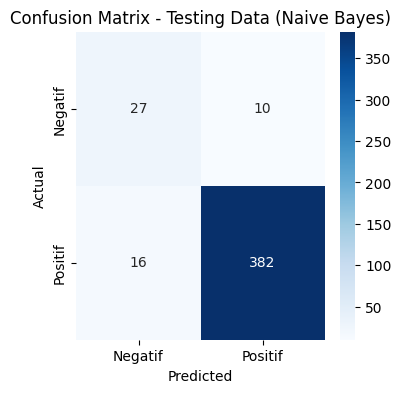

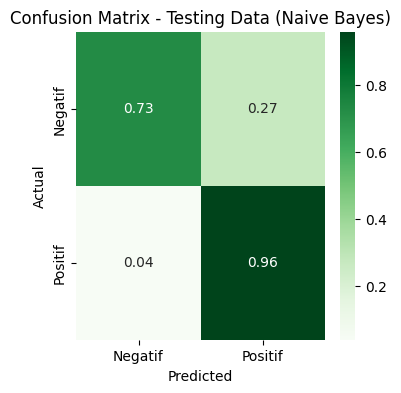

In [272]:
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,log_loss)
# Prediksi
y_pred = nbm.predict(X_test_tfidf)
y_proba = nbm.predict_proba(X_test_tfidf)
# Evaluasi
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')
loss = log_loss(y_test, y_proba)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print("TESTING EVALUATION (NAIVE BAYES)")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Log Loss  : {loss:.4f}")
print(f"Balanced Acc: {bal_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negatif", "Positif"]
))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (Naive Bayes)")
plt.show()
# Confusion Matrix (normalized by true label)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (Naive Bayes)")
plt.show()


# Suport Vector Machine (SVM)

In [273]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 2]
}

svm = LinearSVC(
    class_weight="balanced",
    max_iter=15000,
    random_state=42,
    dual=False
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=1
)


In [274]:
grid.fit(X_train_bal, y_train_bal)


,estimator,LinearSVC(cla...ndom_state=42)
,param_grid,"{'C': [0.01, 0.05, ...]}"
,scoring,'f1_macro'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [275]:
svm = grid.best_estimator_


In [276]:
print("Best C:", grid.best_params_)
print("Best CV F1_macro:", grid.best_score_)
print("Best estimator:", grid.best_estimator_)


Best C: {'C': 2}
Best CV F1_macro: 0.9880630020091508
Best estimator: LinearSVC(C=2, class_weight='balanced', dual=False, max_iter=15000,
          random_state=42)


Training

TRAINING EVALUATION
Accuracy (Train): 1.0
Hinge Loss (Train): 0.02851468726334034

Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00      1592

    accuracy                           1.00      1740
   macro avg       1.00      1.00      1.00      1740
weighted avg       1.00      1.00      1.00      1740



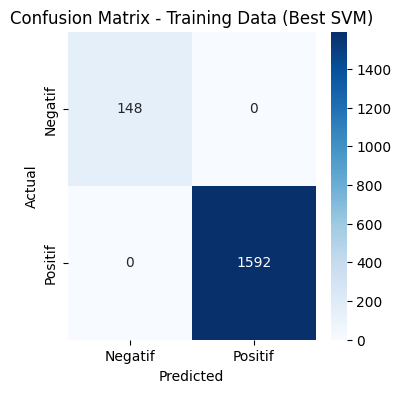

In [277]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, hinge_loss
# Prediksi data testing
print("TRAINING EVALUATION")

y_pred = svm.predict(X_train_tfidf)
y_score = svm.decision_function(X_train_tfidf)

train_acc = accuracy_score(y_train, y_pred)
train_loss = hinge_loss(y_train, y_score)

print("Accuracy (Train):", train_acc)
print("Hinge Loss (Train):", train_loss)
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred))
#confusing matrix
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Data (Best SVM)")
plt.show()


Testing

TESTING EVALUATION (SVM)
Accuracy   : 0.9540
Precision  : 0.9514
Recall     : 0.9540
F1-Score   : 0.9522
Hinge Loss : 0.1565
Balanced Acc: 0.8155

Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.77      0.65      0.71        37
     Positif       0.97      0.98      0.98       398

    accuracy                           0.95       435
   macro avg       0.87      0.82      0.84       435
weighted avg       0.95      0.95      0.95       435



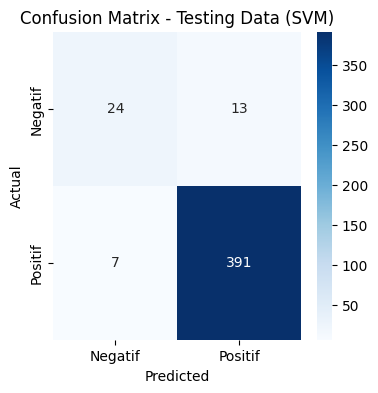

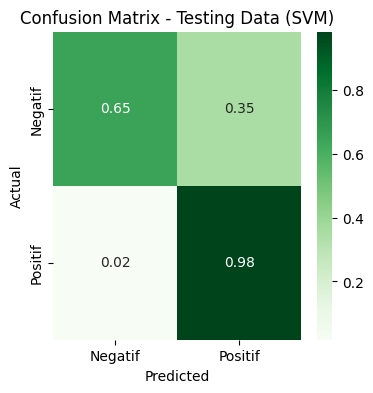

In [278]:
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,hinge_loss)

print("TESTING EVALUATION (SVM)")
y_pred = svm.predict(X_test_tfidf)
y_score = svm.decision_function(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
loss = hinge_loss(y_test, y_score)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"Hinge Loss : {loss:.4f}")
print(f"Balanced Acc: {bal_acc:.4f}")

print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negatif", "Positif"]))

cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (SVM)")
plt.show()
plt.figure(figsize=(4,4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (SVM)")
plt.show()


Download Model TF-IDF, NB dan SVM

In [280]:
import ast
import json
import pickle
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    log_loss,
    hinge_loss
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

# 1) Siapkan data dari hasil pipeline in-memory
export_df = data.copy()

def safe_eval_export(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            return v if isinstance(v, list) else []
        except Exception:
            return []
    return []

export_df['stemming'] = export_df['stemming'].apply(safe_eval_export)
export_df = export_df[export_df['stemming'].apply(lambda v: isinstance(v, list) and len(v) > 0)].copy()
export_df['stemming'] = export_df['stemming'].apply(lambda toks: ' '.join(toks))

# 2) Label -> encoded
label_col = 'label'
label_map = {'Negatif': 0, 'Positif': 1}

export_df = export_df[export_df[label_col].isin(label_map.keys())].copy()
export_df['encoded'] = export_df[label_col].map(label_map)

X_all = export_df['stemming']
y_all = export_df['encoded'].astype(int)

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 3) Konfigurasi TF-IDF
tfidf_cfg = dict(
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=2,
    sublinear_tf=True,
    norm='l2'
)

# 4) Train model terpisah
tfidf_export = TfidfVectorizer(**tfidf_cfg)
Xtr_exp = tfidf_export.fit_transform(X_train_exp)
Xte_exp = tfidf_export.transform(X_test_exp)

nb_export = ComplementNB(alpha=0.05)
nb_export.fit(Xtr_exp, y_train_exp)
nb_pred_exp = nb_export.predict(Xte_exp)
nb_proba_exp = nb_export.predict_proba(Xte_exp)

svm_export = LinearSVC(
    C=1,
    class_weight='balanced',
    max_iter=15000,
    dual=False,
    random_state=42
)
svm_export.fit(Xtr_exp, y_train_exp)
svm_pred_exp = svm_export.predict(Xte_exp)
svm_score_exp = svm_export.decision_function(Xte_exp)

# 5) Simpan artifacts
artifacts_dir = Path('model_machine')
artifacts_dir.mkdir(parents=True, exist_ok=True)

with open(artifacts_dir / 'vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_export, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(artifacts_dir / 'naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_export, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(artifacts_dir / 'SVM_model.pkl', 'wb') as f:
    pickle.dump(svm_export, f, protocol=pickle.HIGHEST_PROTOCOL)

metrics_export = {
    'nb': {
        'alpha': 0.05,
        'accuracy': float(accuracy_score(y_test_exp, nb_pred_exp)),
        'precision_weighted': float(precision_score(y_test_exp, nb_pred_exp, average='weighted')),
        'recall_weighted': float(recall_score(y_test_exp, nb_pred_exp, average='weighted')),
        'f1_weighted': float(f1_score(y_test_exp, nb_pred_exp, average='weighted')),
        'f1_macro': float(f1_score(y_test_exp, nb_pred_exp, average='macro')),
        'balanced_accuracy': float(balanced_accuracy_score(y_test_exp, nb_pred_exp)),
        'log_loss': float(log_loss(y_test_exp, nb_proba_exp))
    },
    'svm': {
        'C': 1,
        'accuracy': float(accuracy_score(y_test_exp, svm_pred_exp)),
        'precision_weighted': float(precision_score(y_test_exp, svm_pred_exp, average='weighted')),
        'recall_weighted': float(recall_score(y_test_exp, svm_pred_exp, average='weighted')),
        'f1_weighted': float(f1_score(y_test_exp, svm_pred_exp, average='weighted')),
        'f1_macro': float(f1_score(y_test_exp, svm_pred_exp, average='macro')),
        'balanced_accuracy': float(balanced_accuracy_score(y_test_exp, svm_pred_exp)),
        'hinge_loss': float(hinge_loss(y_test_exp, svm_score_exp))
    },
    'tfidf_vocab_size': int(len(tfidf_export.vocabulary_)),
    'smote': False
}

with open(artifacts_dir / 'metrics_nb_svm.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_export, f, indent=2)

print('Artifacts berhasil dibuat di:', artifacts_dir.resolve())
print(json.dumps(metrics_export, indent=2))


Artifacts berhasil dibuat di: D:\PROYEK TUGAS AKHIR\APP TA\analisis\model_machine
{
  "nb": {
    "alpha": 0.05,
    "accuracy": 0.9172413793103448,
    "precision_weighted": 0.950647251001365,
    "recall_weighted": 0.9172413793103448,
    "f1_weighted": 0.9275571192110311,
    "f1_macro": 0.8034243824061056,
    "balanced_accuracy": 0.9180021730272987,
    "log_loss": 0.19717326342141714
  },
  "svm": {
    "C": 1,
    "accuracy": 0.960919540229885,
    "precision_weighted": 0.9604605383189774,
    "recall_weighted": 0.960919540229885,
    "f1_weighted": 0.9606763830748554,
    "f1_macro": 0.8728966501091422,
    "balanced_accuracy": 0.8683281271220971,
    "hinge_loss": 0.18395507439985398
  },
  "tfidf_vocab_size": 5123,
  "smote": false
}


In [ ]:
# import pickle
# from pathlib import Path

# # path folder model
# model_dir = Path(r"D:\PROYEK TUGAS AKHIR\APP TA\analisis\model_machine")  # sesuaikan bila perlu

# # load artifacts
# with open(model_dir / 'vectorizer.pkl', 'rb') as f:
#     vectorizer = pickle.load(f)

# with open(model_dir / 'naive_bayes_model.pkl', 'rb') as f:
#     nb_model = pickle.load(f)

# with open(model_dir / 'SVM_model.pkl', 'rb') as f:
#     svm_model = pickle.load(f)

# # input manual
# ulasan = input("Masukkan ulasan: ").strip()

# # transform
# X = vectorizer.transform([ulasan])

# # predict
# nb_pred = nb_model.predict(X)[0]
# svm_pred = svm_model.predict(X)[0]

# label_map = {0: 'Negatif', 1: 'Positif'}

# print("NB  :", label_map.get(int(nb_pred), nb_pred))
# print("SVM :", label_map.get(int(svm_pred), svm_pred))


NB  : Negatif
SVM : Positif


In [126]:
# from pathlib import Path
# model_dir = Path(r"D:\PROYEK TUGAS AKHIR\APP TA\analisis\model_machine")
# print(model_dir.exists())
# print(list(model_dir.glob("*")))
